In [1]:
# Residency Week Project
## Deliverable 3: Classification, Clustering, and Pattern Mining

# Bilal Khalid
# Advanced Big Data and Data Mining (MSCS-634-M20)
# Online Shoppers Purchasing Intention dataset

In [25]:
# Load Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display plots inside Jupyter Notebook
%matplotlib inline

In [26]:
# Load Dataset

df = pd.read_csv("online_shoppers_intention.csv")

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [28]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [31]:
# Check missing values

df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
# Missing Values Analysis
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [34]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
data = df.copy()

encoder = LabelEncoder()

# List of categorical columns
categorical_columns = [

    "Month",

    "VisitorType",

    "Weekend",

    "Revenue"

]

# Encode each categorical column
for column in categorical_columns:

    data[column] = encoder.fit_transform(data[column])

# Display encoded dataset
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,1,1,1,1,2,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,2,2,2,1,2,2,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,2,4,1,9,3,2,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,2,3,2,2,4,2,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,2,3,3,1,4,2,1,0


In [35]:
# Independent variables
X = df.drop("Revenue", axis=1)

# Target variable
y = data["Revenue"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (12330, 17)
Target Shape: (12330,)


In [41]:
# Convert categorical variables into numeric variables
X = pd.get_dummies(X, columns=["Month", "VisitorType", "Weekend"], drop_first=True)

# Check the new columns
X.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_True
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,False,False,False,False,True,True


In [42]:
from sklearn.model_selection import train_test_split

# Split into training and testing datasets

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print()

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (9864, 26)
Testing Features : (2466, 26)

Training Target : (9864,)
Testing Target : (2466,)


In [43]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (

    accuracy_score,

    f1_score,

    classification_report,

    confusion_matrix,

    ConfusionMatrixDisplay,

    roc_curve,

    auc

)

# Create Decision Tree model
decision_tree = DecisionTreeClassifier(

    random_state=42

)

# Train the model
decision_tree.fit(

    X_train,

    y_train

)

# Predict test data
dt_predictions = decision_tree.predict(X_test)

# Prediction probabilities
dt_probability = decision_tree.predict_proba(X_test)[:,1]

print("Decision Tree Performance")

print("--------------------------")

print("Accuracy :", accuracy_score(y_test, dt_predictions))

print("F1 Score :", f1_score(y_test, dt_predictions))

print()

print(classification_report(

    y_test,

    dt_predictions

))

Decision Tree Performance
--------------------------
Accuracy : 0.8617193836171938
F1 Score : 0.5565669700910273

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      2084
           1       0.55      0.56      0.56       382

    accuracy                           0.86      2466
   macro avg       0.74      0.74      0.74      2466
weighted avg       0.86      0.86      0.86      2466



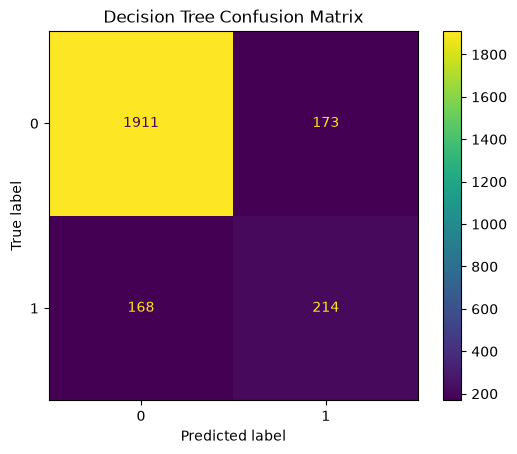

In [44]:
cm = confusion_matrix(

    y_test,

    dt_predictions

)

ConfusionMatrixDisplay(

    confusion_matrix=cm

).plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()

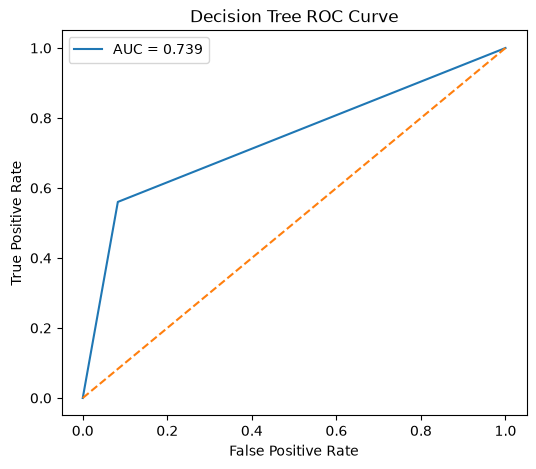

In [45]:
fpr, tpr, threshold = roc_curve(

    y_test,

    dt_probability

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

In [46]:
from sklearn.ensemble import RandomForestClassifier

# Create model
random_forest = RandomForestClassifier(

    random_state=42

)

# Train model
random_forest.fit(

    X_train,

    y_train

)

# Predictions
rf_predictions = random_forest.predict(

    X_test

)

rf_probability = random_forest.predict_proba(

    X_test

)[:,1]

print("Random Forest Performance")

print("--------------------------")

print("Accuracy :", accuracy_score(

    y_test,

    rf_predictions

))

print("F1 Score :", f1_score(

    y_test,

    rf_predictions

))

print()

print(classification_report(

    y_test,

    rf_predictions

))

Random Forest Performance
--------------------------
Accuracy : 0.9010543390105434
F1 Score : 0.6314199395770392

              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.75      0.55      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466



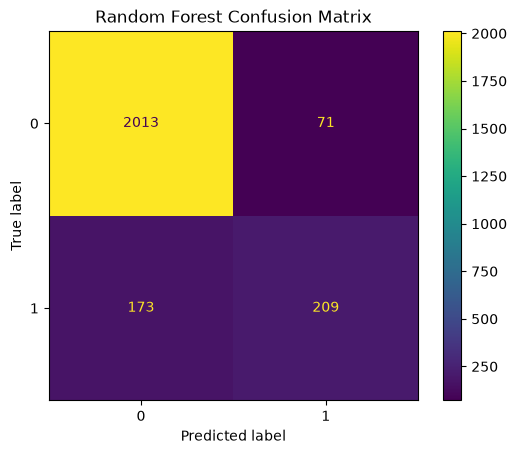

In [47]:
cm = confusion_matrix(

    y_test,

    rf_predictions

)

ConfusionMatrixDisplay(

    confusion_matrix=cm

).plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

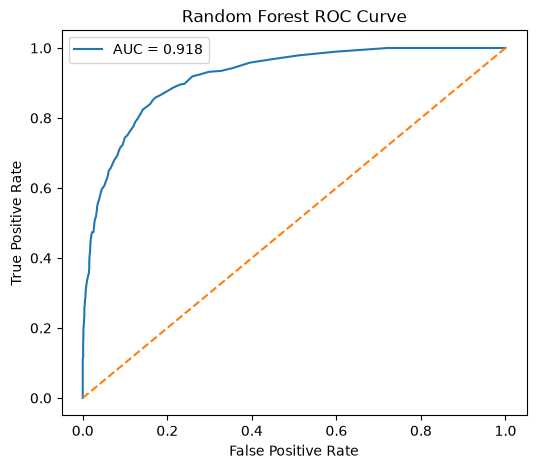

In [48]:
fpr, tpr, threshold = roc_curve(

    y_test,

    rf_probability

)

roc_auc = auc(

    fpr,

    tpr

)

plt.figure(figsize=(6,5))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {roc_auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.show()

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [50]:
# Candidate values of k
parameters = {
    "n_neighbors": [3,5,7,9,11]
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=parameters,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [51]:
print("Best Parameters")
print(grid_search.best_params_)

print()

print("Best Cross Validation Accuracy")
print(grid_search.best_score_)

Best Parameters
{'n_neighbors': 11}

Best Cross Validation Accuracy
0.8643552050038605


In [52]:
best_knn = grid_search.best_estimator_

knn_predictions = best_knn.predict(X_test)

knn_probability = best_knn.predict_proba(X_test)[:,1]

In [53]:
print("k-NN Performance")
print("----------------------")

print("Accuracy:",
      accuracy_score(y_test, knn_predictions))

print("F1 Score:",
      f1_score(y_test, knn_predictions))

print()

print(classification_report(
    y_test,
    knn_predictions
))

k-NN Performance
----------------------
Accuracy: 0.8580697485806975
F1 Score: 0.29435483870967744

              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2084
           1       0.64      0.19      0.29       382

    accuracy                           0.86      2466
   macro avg       0.75      0.59      0.61      2466
weighted avg       0.83      0.86      0.82      2466



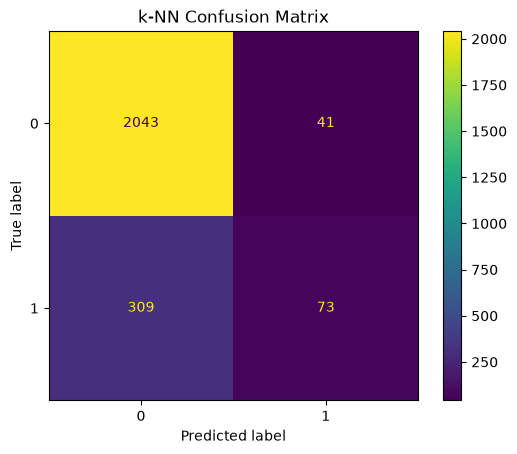

In [54]:
cm = confusion_matrix(
    y_test,
    knn_predictions
)

display = ConfusionMatrixDisplay(cm)

display.plot()

plt.title("k-NN Confusion Matrix")

plt.show()

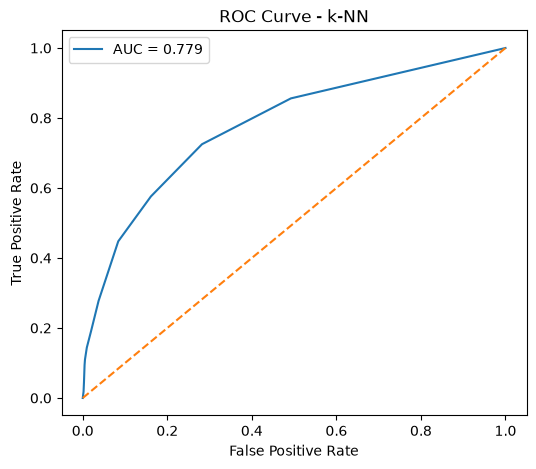

In [55]:
fpr,tpr,_ = roc_curve(
    y_test,
    knn_probability
)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f"%roc_auc
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - k-NN")

plt.legend()

plt.show()

In [56]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [57]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

In [58]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

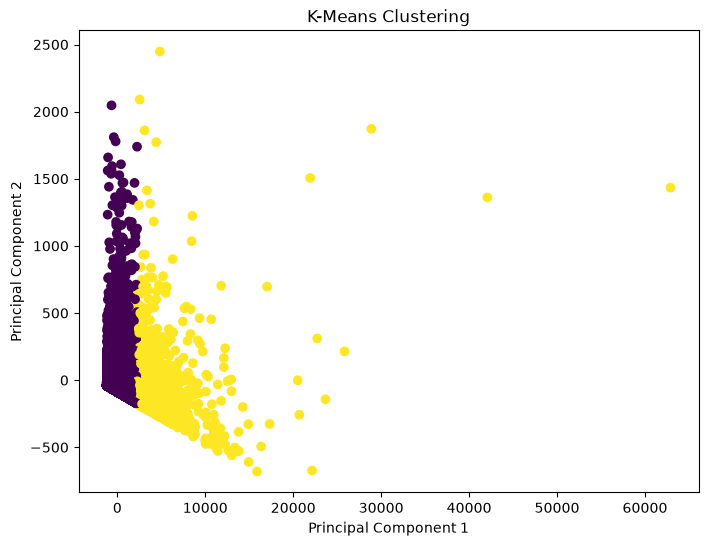

In [59]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis"
)

plt.title("K-Means Clustering")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

In [60]:
cluster_summary = pd.Series(clusters).value_counts()

print(cluster_summary)

0    11397
1      933
Name: count, dtype: int64


In [61]:
transactions = []

for _, row in df.iterrows():

    transaction = [

        str(row["Month"]),

        str(row["VisitorType"]),

        "Weekend" if row["Weekend"] else "Weekday",

        "Revenue" if row["Revenue"] else "NoRevenue"

    ]

    transactions.append(transaction)

In [62]:
from mlxtend.preprocessing import TransactionEncoder

encoder = TransactionEncoder()

encoded = encoder.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    encoded,
    columns=encoder.columns_
)

In [63]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [64]:
frequent_items = apriori(
    basket,
    min_support=0.20,
    use_colnames=True
)

frequent_items.head()

,support,itemsets
0,0.272830,(May)
1,0.845255,(NoRevenue)
2,0.243147,(Nov)
3,0.855718,(Returning_Visitor)
4,0.767397,(Weekday)


In [65]:
rules = association_rules(
    frequent_items,
    metric="confidence",
    min_threshold=0.60
)

rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules.head(10)

,antecedents,consequents,support,confidence,lift
0,(May),(NoRevenue),0.243228,0.891498,1.054709
1,(May),(Returning_Visitor),0.246959,0.905172,1.057793
2,(May),(Weekday),0.214842,0.787455,1.026139
3,(NoRevenue),(Returning_Visitor),0.736496,0.871330,1.018244
4,(Returning_Visitor),(NoRevenue),0.736496,0.860677,1.018244
5,(NoRevenue),(Weekday),0.653122,0.772692,1.006901
6,(Weekday),(NoRevenue),0.653122,0.851089,1.006901
7,(Nov),(Returning_Visitor),0.207380,0.852902,0.996709
8,(Returning_Visitor),(Weekday),0.662530,0.774239,1.008917
9,(Weekday),(Returning_Visitor),0.662530,0.863348,1.008917


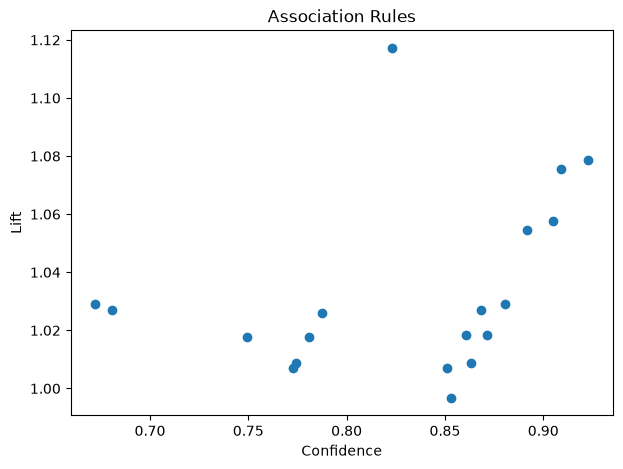

In [66]:
plt.figure(figsize=(7,5))

plt.scatter(
    rules["confidence"],
    rules["lift"]
)

plt.xlabel("Confidence")

plt.ylabel("Lift")

plt.title("Association Rules")

plt.show()

In [67]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "k-NN"
    ],

    "Accuracy":[

        accuracy_score(y_test,dt_predictions),

        accuracy_score(y_test,knn_predictions)

    ],

    "F1 Score":[

        f1_score(y_test,dt_predictions),

        f1_score(y_test,knn_predictions)

    ]

})

comparison

,Model,Accuracy,F1 Score
0,Decision Tree,0.861719,0.556567
1,k-NN,0.858070,0.294355
